In [1]:
# Импорты сюдаа
import numpy as np
import matplotlib.pyplot as plt

In [1]:
class RickerWaveletGenerator:
    """
    Генератор синтетических сейсмических трасс на основе свёрточной модели.
    """
    
    def __init__(self, wavelet_type='ricker', wavelet_freq=30, dt=0.002, length=0.128):
        """
        Инициализация генератора.

        Параметры:
        ----------
        wavelet_type : str
            Тип импульса источника ('ricker')
        wavelet_freq : float
            Доминантная частота импульса (Гц)
        dt : float
            Интервал дискретизации по времени (секунды)
        """
        self.wavelet_type = wavelet_type
        self.wavelet_freq = wavelet_freq
        self.length = length
        self.dt = dt
        
        self.wavelet_time, self.wavelet = self._create_ricker_wavelet()
    
    def _create_ricker_wavelet(self):
        """
        Создаёт вейвлет Рикера заданной длительности.

        Параметры:
        ----------
        length : float
            Длительность импульса в секундах (должна быть достаточно большой,
            чтобы импульс затух до нуля)
        """
        # Временная сетка для импульса
        t = np.arange(-self.length/2, self.length/2, self.dt) #создаёт массив чисел от -0.064 до 0.064 с шагом self.dt (0.002 сек)
        f = self.wavelet_freq
        
        # Формула вейвлета Рикера
        tau = np.pi * f * t
        wavelet = (1 - 2 * tau**2) * np.exp(-tau**2)
        
        # Нормализация (максимальная амплитуда = 1)
        wavelet = wavelet / np.max(np.abs(wavelet))
        
        return t, wavelet
    
    def get_wavelet(self):
        """
        Возвращает импульс источника (создаёт, если ещё не создан).
        """
        if self.wavelet is None:
            if self.wavelet_type == 'ricker':
                t, w = self._create_ricker_wavelet()
                self.wavelet_time = t
                self.wavelet = w
            else:
                raise ValueError(f"Неподдерживаемый тип вейвлета: {self.wavelet_type}")
        return self.wavelet_time, self.wavelet
    
    def generate_trace(self, reflectivity_series, noise_level=0.0):
        """
        Генерирует сейсмическую трассу по коэффициентам отражения.

        Параметры:
        ----------
        reflectivity_series : np.ndarray
            Массив коэффициентов отражения (по времени) — например,
            [0, 0, 0.3, 0, -0.1, 0, ...]
            Длина массива определяет длительность трассы в отсчётах.
        noise_level : float
            Уровень аддитивного белого шума (0 = нет шума, 0.1 = 10% от RMS сигнала)

        Возвращает:
        ----------
        trace : np.ndarray
            Синтетическая трасса (той же длины, что reflectivity_series)
        """
        # 1. Получаем импульс источника
        wavelet = self.get_wavelet()
        
        # 2. Свёртка коэффициентов отражения с импульсом
        #    'full' -> полная свёртка, потом обрезаем до длины reflectivity_series
        trace_full = np.convolve(reflectivity_series, wavelet, mode='full')
        
        # 3. Обрезаем до нужной длины (чтобы сохранить временную ось как у reflectivity_series)
        trace = trace_full[:len(reflectivity_series)]
        
        # 4. Добавляем шум (если нужно)
        if noise_level > 0:
            # Оцениваем RMS сигнала
            rms_signal = np.sqrt(np.mean(trace**2))
            # Генерируем шум
            noise = np.random.randn(len(trace)) * noise_level * rms_signal
            trace = trace + noise
        
        return trace
    
    def plot_wavelet(self):
        """Визуализирует импульс источника."""
        wavelet = self.get_wavelet()
        plt.figure(figsize=(5, 2))
        plt.plot(self.wavelet_time, wavelet)
        plt.title(f"Импульс источника по умолчанию ({self.wavelet_type}, freq={self.wavelet_freq} Гц)")
        plt.xlabel("Время (с)")
        plt.ylabel("Амплитуда")
        plt.grid(True)
        plt.show()

In [2]:
class ReflectionCoefficients:
    """
    Расчёт коэффициентов отражения для горизонтально-слоистой среды.
    """
    
    def __init__(self, depths, velocities, densities):
        """
        depths     : np.ndarray
                глубины границ от поверхности (м)
                Например: [500, 1200] — границы на 500м и 1200м
        velocities : np.ndarray
                скорости в слоях (м/с)
                Длина = len(depths) + 1
        densities  : np.ndarray
                плотности в слоях (кг/м³)
                Длина = len(depths) + 1
        """
        self.depths = np.array(depths)
        self.velocities = np.array(velocities)
        self.densities = np.array(densities)
        self.num_layers = len(velocities)
        self.num_boundaries = len(depths)
        
        # Расчёт
        self.impedances = self._compute_impedances()
        self.reflection_coeffs = self._compute_reflection_coeffs()
        self.two_way_times = self._compute_times()
    
    def _compute_impedances(self):
        """Акустический импеданс Z = ρ * V."""
        return self.densities * self.velocities
    
    def _compute_reflection_coeffs(self):
        """Коэффициент отражения R = (Z₂ - Z₁) / (Z₂ + Z₁)."""
        R = []
        for i in range(self.num_boundaries):
            Z_upper = self.impedances[i]
            Z_lower = self.impedances[i+1]
            coeff = (Z_lower - Z_upper) / (Z_lower + Z_upper)
            R.append(coeff)
        return np.array(R)
    
    def _compute_times(self):
        """
        Двустороннее время прихода отражённой волны от каждой границы.
        """
        times = []
        cumulative = 0.0
        
        for i in range(self.num_boundaries):
            if i == 0:
                thickness = self.depths[0]
            else:
                thickness = self.depths[i] - self.depths[i-1]
            
            cumulative += 2 * thickness / self.velocities[i]
            times.append(cumulative)
        
        return np.array(times)
    
    def get_reflectivity_series(self, dt, total_time):
        """
        Преобразует коэффициенты в дискретный временной ряд.
        
        dt         : float
                интервал дискретизации (с)
        total_time : float
                полное время записи (с)
        
        Возвращает:
        time_axis : ndarray, reflectivity_series : ndarray
        """
        num_samples = int(total_time / dt) + 1
        time_axis = np.arange(0, total_time + dt, dt)[:num_samples]
        reflectivity = np.zeros(num_samples)
        
        for t, r in zip(self.two_way_times, self.reflection_coeffs):
            idx = int(round(t / dt))
            if idx < num_samples:
                reflectivity[idx] = r
        
        return time_axis, reflectivity
    
    def print_summary(self):
        """Вывод геологической модели в консоль."""
        print("=" * 70)
        print("ГЕОЛОГИЧЕСКАЯ МОДЕЛЬ")
        print("=" * 70)
        
        # Заголовок таблицы
        print(f"{'Слой':<6} {'V (м/с)':<10} {'ρ (кг/м³)':<12} {'Z (кг/(м²·с))':<18} {'Толщина':<12}")
        print("-" * 70)
        
        # Слой 0 (до первой границы)
        print(f"{'0':<6} {self.velocities[0]:<10.0f} {self.densities[0]:<12.1f} {self.impedances[0]:<18.2f} {self.depths[0]:<12.1f} м")
        
        # Промежуточные слои
        for i in range(1, self.num_layers - 1):
            thickness = self.depths[i] - self.depths[i-1]
            print(f"{i:<6} {self.velocities[i]:<10.0f} {self.densities[i]:<12.1f} {self.impedances[i]:<18.2f} {thickness:<12.1f} м")
        
        # Последний слой (полубесконечный)
        if self.num_layers > 1:
            last_thickness = "∞"
            print(f"{self.num_layers-1:<6} {self.velocities[-1]:<10.0f} {self.densities[-1]:<12.1f} {self.impedances[-1]:<18.2f} {last_thickness:<12}")
        
        print("\n" + "=" * 70)
        print("ГРАНИЦЫ")
        print("=" * 70)
        for i in range(self.num_boundaries):
            sign = "+" if self.reflection_coeffs[i] >= 0 else "-"
            print(f"Граница {i+1}: глубина {self.depths[i]} м, R = {self.reflection_coeffs[i]:.4f} ({sign}), t = {self.two_way_times[i]:.4f} с")


In [28]:
class SeismicTraceGenerator:
    """
    Генератор синтетической трассы.
    """
    
    def __init__(self, wavelet_freq=30, dt=0.002, noise_level=0.0):
        """
        wavelet_freq : float
                доминантная частота вейвлета (Гц)
        dt           : float
                интервал дискретизации (с)
        noise_level  : float
                уровень шума (0 = без шума, 0.05 = 5% от RMS сигнала)
        """
        self.wavelet_freq = wavelet_freq
        self.dt = dt
        self.noise_level = noise_level
        
        # Создаём вейвлет
        wavelet = RickerWaveletGenerator(wavelet_freq=wavelet_freq, dt=dt, length=0.2)
        self.wavelet_time, self.wavelet = wavelet.get_wavelet()
    
    def _add_noise(self, trace):
        """Добавляет шум с уровнем относительно RMS сигнала."""
        if self.noise_level <= 0:
            return trace
        
        rms = np.sqrt(np.mean(trace**2))
        if rms > 0:
            noise = np.random.randn(len(trace)) * self.noise_level * rms
            return trace + noise
        return trace
    
    def generate_from_reflectivity(self, reflectivity_series):
        """
        Генерация трассы из временного ряда коэффициентов отражения.
        
        Используется mode='full' для точного позиционирования импульса.
        """
        # Полная свёртка
        trace_full = np.convolve(reflectivity_series, self.wavelet, mode='full')
        
        # Обрезаем до длины исходного ряда
        trace = trace_full[:len(reflectivity_series)]
        
        # Добавляем шум
        trace = self._add_noise(trace)
        
        return trace
    
    def generate_from_model(self, depths, velocities, densities, total_time):
        """
        Полный конвейер: геология → трасса.
        
        Возвращает:
        time_axis, trace, rc_model
        """
        # Шаг 1: коэффициенты отражения
        rc = ReflectionCoefficients(depths, velocities, densities)
        
        # Шаг 2: временной ряд коэффициентов
        time_axis, reflectivity = rc.get_reflectivity_series(self.dt, total_time)
        
        # Шаг 3: свёртка с вейвлетом
        trace = self.generate_from_reflectivity(reflectivity)
        
        return time_axis, trace, rc
    
    def visualize_full(self, depths, velocities, densities, total_time):
        """
        Комплексная визуализация всей цепочки:
        1. Скоростная модель
        2. Импедансы слоёв
        3. Коэффициенты отражения
        4. Синтетическая трасса
        """
        # Генерируем трассу
        time_axis, trace, rc = self.generate_from_model(depths, velocities, densities, total_time)
        
        # Получаем временной ряд коэффициентов
        _, reflectivity = rc.get_reflectivity_series(self.dt, total_time)
        
        # Создаём фигуру из 4 подграфиков
        fig, axes = plt.subplots(4, 1, figsize=(10, 8))
        
        # 1. Скоростная модель
        depths_plot = [0] + list(depths)
        velocities_plot = velocities
        axes[0].step(depths_plot + [depths_plot[-1] + 500], 
                     velocities_plot + [velocities_plot[-1]], 
                     where='post', linewidth=2)
        axes[0].set_ylabel("Скорость V, м/с")
        axes[0].set_xlabel("Глубина, м")
        #axes[0].invert_xaxis()
        axes[0].grid(True)
        axes[0].set_title("1. Скоростная модель")
        
        # 2. Импедансы слоёв
        impedances = rc.impedances
        layer_names = [f"Слой {i+1}" for i in range(len(impedances))]
        axes[1].bar(layer_names, impedances, color='lightblue', edgecolor='black')
        axes[1].set_ylabel("Акустический импеданс Z = ρ·V")
        axes[1].set_title("2. Импедансы слоёв")
        axes[1].grid(True, axis='y')
        
        # 3. Коэффициенты отражения
        R = rc.reflection_coeffs
        boundary_names = [f"Гр.{i+1}" for i in range(len(R))]
        colors = ['green' if r >= 0 else 'red' for r in R]
        axes[2].bar(boundary_names, R, color=colors, edgecolor='black')
        axes[2].axhline(y=0, color='black', linewidth=1)
        axes[2].set_ylabel("Коэффициент отражения R")
        axes[2].set_title("3. Коэффициенты отражения на границах")
        axes[2].grid(True, axis='y')
        
        # 4. Синтетическая трасса
        axes[3].plot(time_axis, trace, 'b-', linewidth=1.5)
        axes[3].set_xlabel("Время, с")
        axes[3].set_ylabel("Амплитуда")
        axes[3].set_title("4. Синтетическая сейсмическая трасса")
        axes[3].grid(True)
        
        # Отмечаем времена прихода границ
        for t in rc.two_way_times:
            axes[3].axvline(x=t, color='red', linestyle='--', alpha=0.5, linewidth=1)
        
        plt.tight_layout()
        plt.show()
        
        return time_axis, trace, rc


In [61]:
depths_ex1 = [500, 550, 560, 670, 1200, 1500]           # границы на 500м, 550м, 560м, 1200м и 1500м
velocities_ex1 = [2000, 1900, 2000, 1700, 2300, 2000, 1900]  # скорости слоёв
densities_ex1 = [2200, 2000, 2100, 2300, 2000, 2500, 2500]   # плотности слоёв (кг/м³)

In [62]:
# Генератор
gen1 = SeismicTraceGenerator(wavelet_freq=30, dt=0.002, noise_level=0.2)

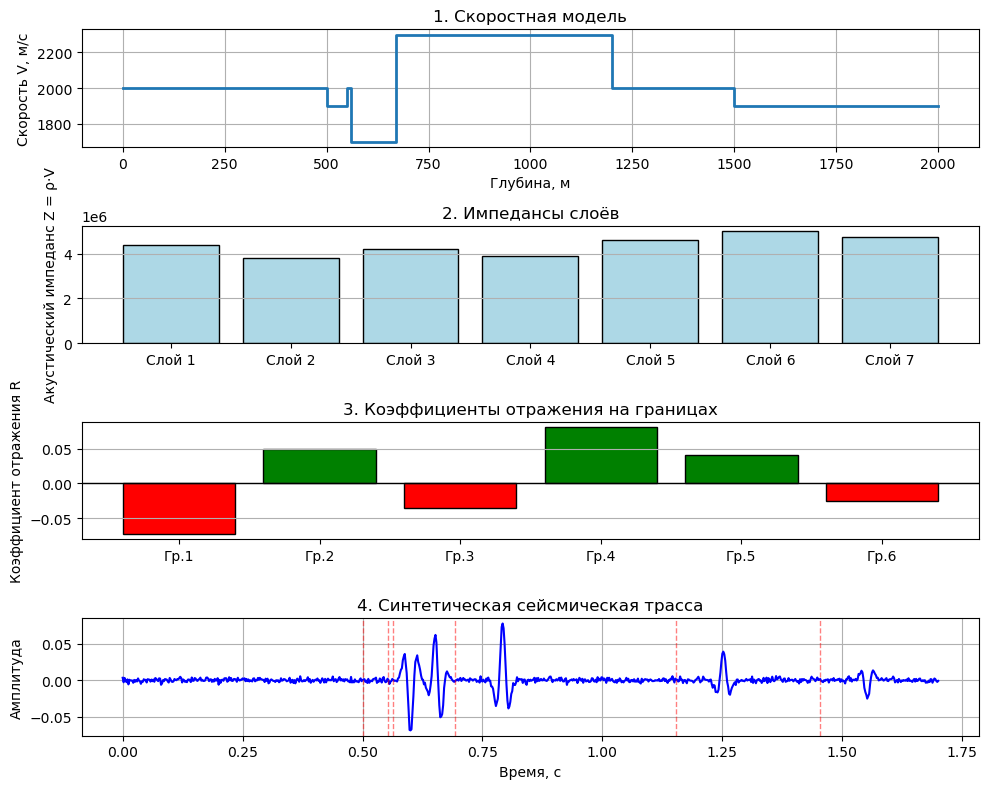

In [63]:
time_axis1, trace1, rc1 = gen1.visualize_full(depths_ex1, velocities_ex1, densities_ex1, total_time=1.7)

In [18]:
rc1.print_summary()

ГЕОЛОГИЧЕСКАЯ МОДЕЛЬ
Слой   V (м/с)    ρ (кг/м³)    Z (кг/(м²·с))      Толщина     
----------------------------------------------------------------------
0      2000       2200.0       4400000.00         500.0        м
1      1900       2000.0       3800000.00         50.0         м
2      1700       2300.0       3910000.00         10.0         м
3      2500       2400.0       6000000.00         640.0        м
4      3500       2500.0       8750000.00         ∞           

ГРАНИЦЫ
Граница 1: глубина 500 м, R = -0.0732 (-), t = 0.5000 с
Граница 2: глубина 550 м, R = 0.0143 (+), t = 0.5526 с
Граница 3: глубина 560 м, R = 0.2109 (+), t = 0.5644 с
Граница 4: глубина 1200 м, R = 0.1864 (+), t = 1.0764 с


In [46]:
depths_ex2 = [800]
velocities_ex2 = [1500, 2000]
densities_ex2 = [2600, 2100]

In [47]:
gen2 = SeismicTraceGenerator(wavelet_freq=30, dt=0.002, noise_level=0.0)

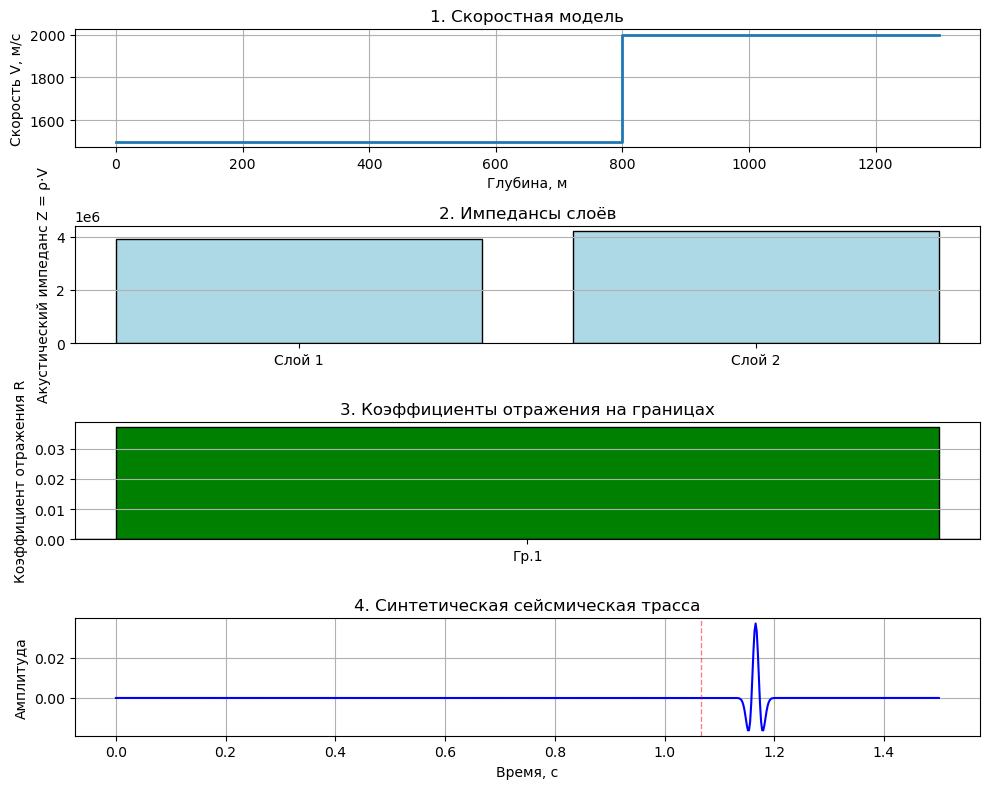

In [48]:
time_axis2, trace2, rc2 = gen2.visualize_full(depths_ex2, velocities_ex2, densities_ex2, total_time=1.5)

In [27]:
rc2.print_summary()

ГЕОЛОГИЧЕСКАЯ МОДЕЛЬ
Слой   V (м/с)    ρ (кг/м³)    Z (кг/(м²·с))      Толщина     
----------------------------------------------------------------------
0      1500       2600.0       3900000.00         800.0        м
1      2000       2100.0       4200000.00         ∞           

ГРАНИЦЫ
Граница 1: глубина 800 м, R = 0.0370 (+), t = 1.0667 с


In [23]:
# ПРОГА ОРИЕНТИРУЕТСЯ ОТ ВРЕМЕНИ, НАДО ОТ ОТСЧЕТОВ